Libraries loaded successfully
Upload DEPREM-DORT-SEHIR-eng.xlsx file:


Saving DEPREM-DORT-SEHIR-eng.xlsx to DEPREM-DORT-SEHIR-eng (2).xlsx
DEPREM-DORT-SEHIR-eng (2).xlsx uploaded successfully
Earthquake data shape: (149, 9)
Upload KONUT-DORT-SEHIR.xls file:


Saving KONUT-DORT-SEHIR.xls to KONUT-DORT-SEHIR (2).xls
KONUT-DORT-SEHIR (2).xls uploaded successfully
Housing data shape: (12, 51)
PROCESSING EARTHQUAKE DATA
Date information added
                 Date  Location  Magnitude  Year  Month
0 2020-01-11 13:37:36  Istanbul        4.7  2020      1
1 2019-09-26 11:26:36  Istanbul        4.1  2019      9
2 2019-09-26 10:59:25  Istanbul        5.8  2019      9
3 2019-09-24 08:00:22  Istanbul        4.6  2019      9
4 2015-12-15 01:13:39  Istanbul        4.0  2015     12
PROCESSING HOUSING DATA
Housing data structure analysis
             Unnamed: 0     Unnamed: 1  Unnamed: 2  Sütunlar Unnamed: 4  \
0              Satırlar            NaN         NaN  Ankara-6        NaN   
1                   NaN            NaN         NaN   01-Ocak   02-Şubat   
2                   NaN            NaN         NaN       NaN        NaN   
3  Konut Satış Sayıları  Ölçüm bazında      2015.0      9570      11063   
4                   NaN            NaN      2016.0 

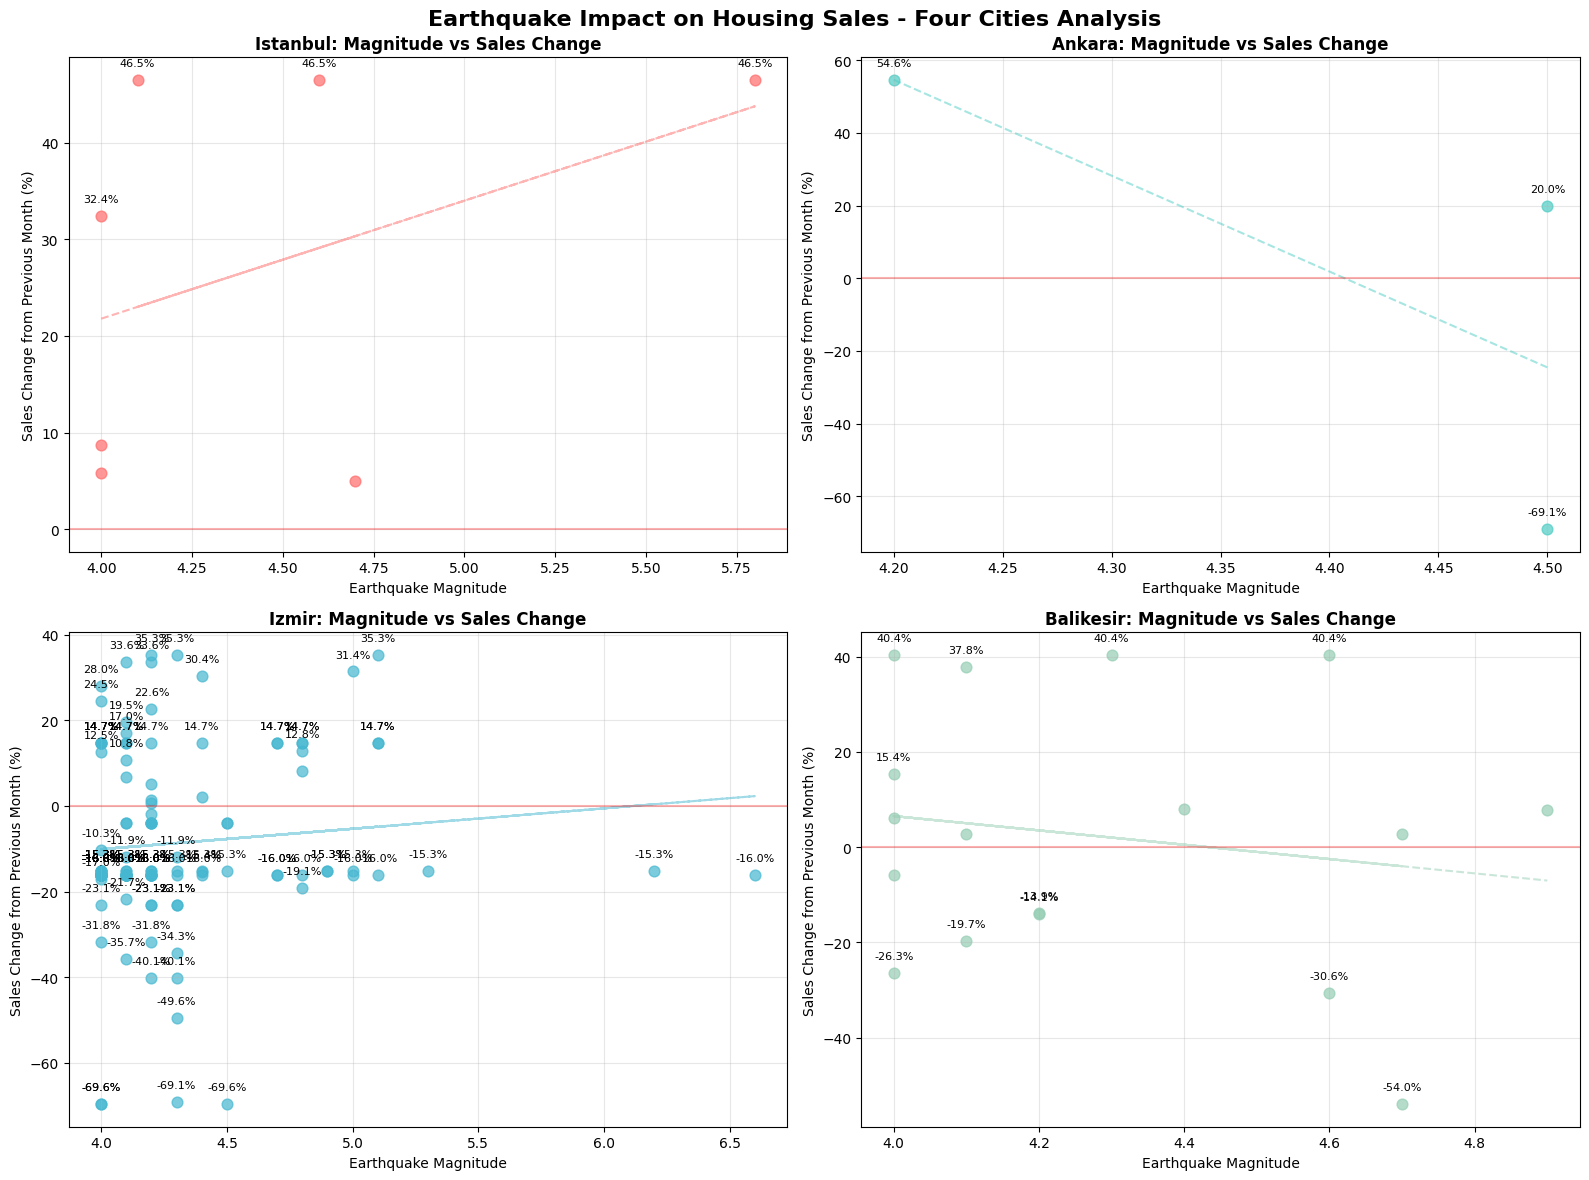

SUMMARY: EARTHQUAKE IMPACT ANALYSIS
TOTAL SIGNIFICANT EARTHQUAKES (M>=4.0): 149
CITIES AFFECTED: 4
EARTHQUAKES BY CITY (M>=4.0):
  Izmir: 122 earthquakes (Avg M4.3)
  Balikesir: 17 earthquakes (Avg M4.3)
  Istanbul: 7 earthquakes (Avg M4.5)
  Ankara: 3 earthquakes (Avg M4.4)

IMPACT ANALYSIS RESULTS:
Earthquakes with housing data: 149
Average monthly sales change: -5.5%
Earthquakes with negative sales impact: 95
Earthquakes with positive sales impact: 54

CITY-SPECIFIC IMPACTS:
  Istanbul: 7 earthquakes, avg change: +27.4%
  Ankara: 3 earthquakes, avg change: +1.8%
  Izmir: 122 earthquakes, avg change: -8.6%
  Balikesir: 17 earthquakes, avg change: +2.2%

ANALYSIS COMPLETED


In [3]:
# -*- coding: utf-8 -*-
"""Earthquake Impact on Housing Sales Analysis.ipynb

Automatically generated by Colab.
"""

# ====================
# REQUIRED LIBRARIES
# ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries loaded successfully")

# ====================
# FILE UPLOAD
# ====================
from google.colab import files
import io

print("Upload DEPREM-DORT-SEHIR-eng.xlsx file:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
earthquake_df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f"{file_name} uploaded successfully")
print(f"Earthquake data shape: {earthquake_df.shape}")

print("Upload KONUT-DORT-SEHIR.xls file:")
uploaded_housing = files.upload()

housing_file_name = list(uploaded_housing.keys())[0]
housing_df = pd.read_excel(io.BytesIO(uploaded_housing[housing_file_name]))

print(f"{housing_file_name} uploaded successfully")
print(f"Housing data shape: {housing_df.shape}")

# ====================
# DATA PROCESSING - EARTHQUAKE
# ====================
print("PROCESSING EARTHQUAKE DATA")

earthquake_df['Date'] = pd.to_datetime(earthquake_df['Date'], dayfirst=True)
earthquake_df['Year'] = earthquake_df['Date'].dt.year
earthquake_df['Month'] = earthquake_df['Date'].dt.month
earthquake_df['Year-Month'] = earthquake_df['Date'].dt.to_period('M')

earthquake_df['Location'] = earthquake_df['Location'].str.title()

print("Date information added")
print(earthquake_df[['Date', 'Location', 'Magnitude', 'Year', 'Month']].head())

# ====================
# DATA PROCESSING - HOUSING (FIXED)
# ====================
print("PROCESSING HOUSING DATA")

print("Housing data structure analysis")
print(housing_df.head(10))

print("Row names in housing data:")
for i, row_name in enumerate(housing_df.iloc[:, 0]):
    if pd.notna(row_name):
        print(f"{i}: {row_name}")

# Find the correct row for housing sales data
housing_sales_row_index = None
for i in range(len(housing_df)):
    row_name = housing_df.iloc[i, 0]
    if pd.notna(row_name) and 'Konut Satış Sayıları' in str(row_name):
        housing_sales_row_index = i
        break

print(f"Housing sales data found at row index: {housing_sales_row_index}")

# Extract housing sales data correctly
def extract_city_housing_data_fixed():
    """Extract housing data with correct structure"""
    years = range(2015, 2024)
    city_data = {}

    # City column ranges (adjusted based on actual data structure)
    city_ranges = {
        'Ankara': slice(3, 15),    # Columns 3-14
        'Balikesir': slice(15, 27), # Columns 15-26
        'Istanbul': slice(27, 39),  # Columns 27-38
        'Izmir': slice(39, 51)      # Columns 39-50
    }

    for city, col_range in city_ranges.items():
        city_df = pd.DataFrame()
        city_df['Year'] = years

        # Extract monthly data for each year
        monthly_data = []
        for year_idx, year in enumerate(years):
            # Corrected: Removed '+ 1' from data_row_idx calculation
            data_row_idx = housing_sales_row_index + year_idx  # Data starts at housing_sales_row_index itself
            year_data = []

            for month_idx in range(12):
                col_idx = col_range.start + month_idx
                if col_idx < len(housing_df.columns):
                    value = housing_df.iloc[data_row_idx, col_idx]
                    year_data.append(value)
                else:
                    year_data.append(None)

            monthly_data.append(year_data)

        # Add monthly columns to city dataframe
        months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        for i, month in enumerate(months):
            city_df[month] = [monthly_data[year_idx][i] for year_idx in range(len(years))]

        city_data[city] = city_df

    return city_data

# Extract housing data
city_housing_data = extract_city_housing_data_fixed()

print("Housing data extraction completed")
for city, data in city_housing_data.items():
    print(f"{city}: {len(data)} years of data")
    print(data.head())

# ====================
# EARTHQUAKE IMPACT ANALYSIS
# ====================
print("EARTHQUAKE IMPACT ANALYSIS BY CITY")

significant_earthquakes = earthquake_df[earthquake_df['Magnitude'] >= 4.0].copy()
significant_earthquakes = significant_earthquakes.sort_values('Date')

print(f"Significant earthquakes (Magnitude >= 4.0): {len(significant_earthquakes)}")

analysis_results = []

for city in ['Istanbul', 'Ankara', 'Izmir', 'Balikesir']:
    print(f"ANALYZING {city}")
    print("-" * 40)

    city_quakes = significant_earthquakes[significant_earthquakes['Location'] == city]

    if len(city_quakes) > 0:
        print(f"Significant earthquakes in {city}: {len(city_quakes)}")

        for idx, quake in city_quakes.iterrows():
            quake_date = quake['Date']
            quake_year = quake_date.year
            quake_month = quake_date.month
            magnitude = quake['Magnitude']

            result = {
                'City': city,
                'Date': quake_date,
                'Year': quake_year,
                'Month': quake_month,
                'Magnitude': magnitude,
                'Earthquake_Month_Sales': None,
                'Previous_Month_Sales': None,
                'Next_Month_Sales': None,
                'Change_Previous': None,
                'Change_Next': None
            }

            if city in city_housing_data:
                city_data = city_housing_data[city]
                year_data = city_data[city_data['Year'] == quake_year]

                if not year_data.empty:
                    month_columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
                    if quake_month <= len(month_columns):
                        month_col = month_columns[quake_month - 1]

                        if month_col in year_data.columns:
                            earthquake_month_sales = year_data[month_col].values[0]
                            result['Earthquake_Month_Sales'] = earthquake_month_sales

                            # Previous month
                            prev_month = quake_month - 1 if quake_month > 1 else 12
                            prev_month_col = month_columns[prev_month - 1] if prev_month <= len(month_columns) else None

                            if prev_month_col and prev_month_col in year_data.columns:
                                prev_sales = year_data[prev_month_col].values[0]
                                result['Previous_Month_Sales'] = prev_sales
                                if prev_sales and prev_sales > 0 and earthquake_month_sales:
                                    change = ((earthquake_month_sales - prev_sales) / prev_sales) * 100
                                    result['Change_Previous'] = change

                            # Next month
                            next_month = quake_month + 1 if quake_month < 12 else 1
                            next_month_col = month_columns[next_month - 1] if next_month <= len(month_columns) else None

                            if next_month_col and next_month_col in year_data.columns:
                                next_sales = year_data[next_month_col].values[0]
                                result['Next_Month_Sales'] = next_sales
                                if earthquake_month_sales and earthquake_month_sales > 0 and next_sales:
                                    change_next = ((next_sales - earthquake_month_sales) / earthquake_month_sales) * 100
                                    result['Change_Next'] = change_next

                            analysis_results.append(result)

                            print(f"Earthquake: {quake_date.strftime('%Y-%m')} (M{magnitude})")
                            print(f"Sales in earthquake month: {earthquake_month_sales}")
                            if result['Change_Previous'] is not None:
                                print(f"Change from previous month: {result['Change_Previous']:+.1f}%")
                            if result['Change_Next'] is not None:
                                print(f"Change to next month: {result['Change_Next']:+.1f}%")
                            print()

    else:
        print(f"No significant earthquakes found for {city}")

# Convert results to DataFrame
if analysis_results:
    impact_df = pd.DataFrame(analysis_results)
else:
    impact_df = pd.DataFrame()
    print("No earthquake-housing data matches found")

# ====================
# VISUALIZATION
# ====================
print("VISUALIZATION: EARTHQUAKE IMPACT BY CITY")

if not impact_df.empty:
    # Create 4-panel visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Earthquake Impact on Housing Sales - Four Cities Analysis', fontsize=16, fontweight='bold')

    cities = ['Istanbul', 'Ankara', 'Izmir', 'Balikesir']
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']

    for idx, city in enumerate(cities):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]

        city_quakes = significant_earthquakes[significant_earthquakes['Location'] == city]
        city_impact = impact_df[impact_df['City'] == city]

        if len(city_quakes) > 0 and len(city_impact) > 0:
            # Plot magnitude vs sales change
            magnitudes = city_impact['Magnitude']
            changes = city_impact['Change_Previous']

            ax.scatter(magnitudes, changes, color=colors[idx], s=60, alpha=0.7)

            # Add trend line if enough data points
            if len(city_impact) > 1:
                z = np.polyfit(magnitudes, changes, 1)
                p = np.poly1d(z)
                ax.plot(magnitudes, p(magnitudes), color=colors[idx], alpha=0.5, linestyle='--')

            ax.set_title(f'{city}: Magnitude vs Sales Change', fontweight='bold')
            ax.set_xlabel('Earthquake Magnitude')
            ax.set_ylabel('Sales Change from Previous Month (%)')
            ax.axhline(y=0, color='red', linestyle='-', alpha=0.3)
            ax.grid(True, alpha=0.3)

            # Add data point labels for significant changes
            for i, row in city_impact.iterrows():
                if row['Change_Previous'] is not None and abs(row['Change_Previous']) > 10:
                    ax.annotate(f"{row['Change_Previous']:.1f}%",
                               (row['Magnitude'], row['Change_Previous']),
                               textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

        else:
            ax.text(0.5, 0.5, f'No significant earthquakes\nwith housing data in {city}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{city}', fontweight='bold')

    plt.tight_layout()
    plt.show()

# ====================
# SUMMARY STATISTICS
# ====================
print("SUMMARY: EARTHQUAKE IMPACT ANALYSIS")

total_significant_quakes = len(significant_earthquakes)
cities_with_quakes = significant_earthquakes['Location'].nunique()

print(f"TOTAL SIGNIFICANT EARTHQUAKES (M>=4.0): {total_significant_quakes}")
print(f"CITIES AFFECTED: {cities_with_quakes}")

print("EARTHQUAKES BY CITY (M>=4.0):")
city_summary = significant_earthquakes['Location'].value_counts()
for city, count in city_summary.items():
    avg_magnitude = significant_earthquakes[significant_earthquakes['Location'] == city]['Magnitude'].mean()
    print(f"  {city}: {count} earthquakes (Avg M{avg_magnitude:.1f})")

if not impact_df.empty:
    print("\nIMPACT ANALYSIS RESULTS:")
    print(f"Earthquakes with housing data: {len(impact_df)}")

    valid_changes = impact_df['Change_Previous'].dropna()
    if len(valid_changes) > 0:
        avg_change = valid_changes.mean()
        print(f"Average monthly sales change: {avg_change:+.1f}%")

        negative_impact = len(valid_changes[valid_changes < 0])
        positive_impact = len(valid_changes[valid_changes > 0])

        print(f"Earthquakes with negative sales impact: {negative_impact}")
        print(f"Earthquakes with positive sales impact: {positive_impact}")

        # City-specific impacts
        print("\nCITY-SPECIFIC IMPACTS:")
        for city in cities:
            city_data = impact_df[impact_df['City'] == city]
            city_changes = city_data['Change_Previous'].dropna()
            if len(city_changes) > 0:
                avg_city_change = city_changes.mean()
                print(f"  {city}: {len(city_data)} earthquakes, avg change: {avg_city_change:+.1f}%")

print("\nANALYSIS COMPLETED")